In [2]:
import matplotlib.pyplot as plt 
import pandas as pd  
import numpy as np 
import seaborn as sns

In [3]:
from sklearn.datasets import load_diabetes

In [4]:
import pandas as pd
from sklearn.datasets import load_diabetes

data = load_diabetes()

df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641


In [7]:
print(df.columns)


Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')


In [10]:
X=df[['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']]
y=data['target']

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=22)

In [12]:
corr=X_train.corr()

<AxesSubplot:>

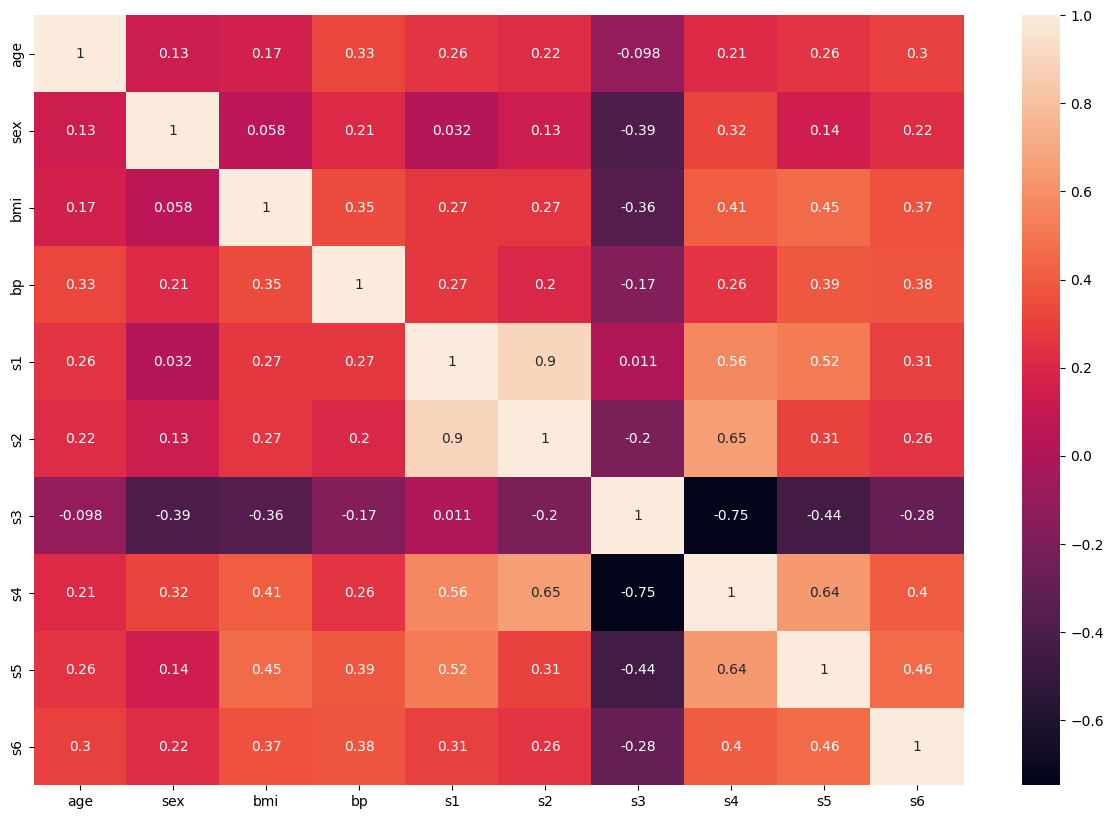

In [14]:
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [16]:
from sklearn.tree import DecisionTreeClassifier
regressor=DecisionTreeClassifier()
regressor.fit(X_train,y_train)

DecisionTreeClassifier()

In [18]:
#hyper toning
param={'criterion':['squared_error','friedman_mse','absolute_error'],'splitter':['best','random'
                    ],'max_depth':[1,2,3,4,5,10,15,20,25],'max_features':['auto','squr',
                                                                        'log2']}

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor


In [30]:
regressor=DecisionTreeRegressor()

()

()

In [31]:
grid=GridSearchCV(regressor,param_grid=param,cv=5,scoring='neg_mean_squared_error')

In [32]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'squr', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [33]:
y_pred=grid.predict(X_test)

In [34]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [35]:
print(r2_score(y_pred,y_test))
print(mean_absolute_error(y_pred,y_test))
print(mean_squared_error(y_pred,y_test))

-0.21115640813226944
47.162876388415334
3473.742279714421


In [40]:
selectmodel=DecisionTreeRegressor(criterion='friedman_mse',max_depth=4,max_features='log2')

In [41]:
selectmodel.fit(X_train,y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=4,
                      max_features='log2')

[Text(581.25, 693.0, 'X[2] <= 0.009\nfriedman_mse = 5879.201\nsamples = 353\nvalue = 152.023'),
 Text(290.625, 539.0, 'X[7] <= 0.031\nfriedman_mse = 4029.931\nsamples = 218\nvalue = 121.339'),
 Text(145.3125, 385.0, 'X[0] <= 0.004\nfriedman_mse = 2852.134\nsamples = 168\nvalue = 105.762'),
 Text(72.65625, 231.0, 'X[6] <= 0.025\nfriedman_mse = 2267.225\nsamples = 93\nvalue = 93.849'),
 Text(36.328125, 77.0, 'friedman_mse = 2808.304\nsamples = 53\nvalue = 106.811'),
 Text(108.984375, 77.0, 'friedman_mse = 1032.719\nsamples = 40\nvalue = 76.675'),
 Text(217.96875, 231.0, 'X[8] <= 0.013\nfriedman_mse = 3183.262\nsamples = 75\nvalue = 120.533'),
 Text(181.640625, 77.0, 'friedman_mse = 2109.155\nsamples = 59\nvalue = 105.78'),
 Text(254.296875, 77.0, 'friedman_mse = 3381.559\nsamples = 16\nvalue = 174.938'),
 Text(435.9375, 385.0, 'X[6] <= -0.023\nfriedman_mse = 4432.458\nsamples = 50\nvalue = 173.68'),
 Text(363.28125, 231.0, 'X[3] <= -0.041\nfriedman_mse = 4310.987\nsamples = 38\nvalue = 1

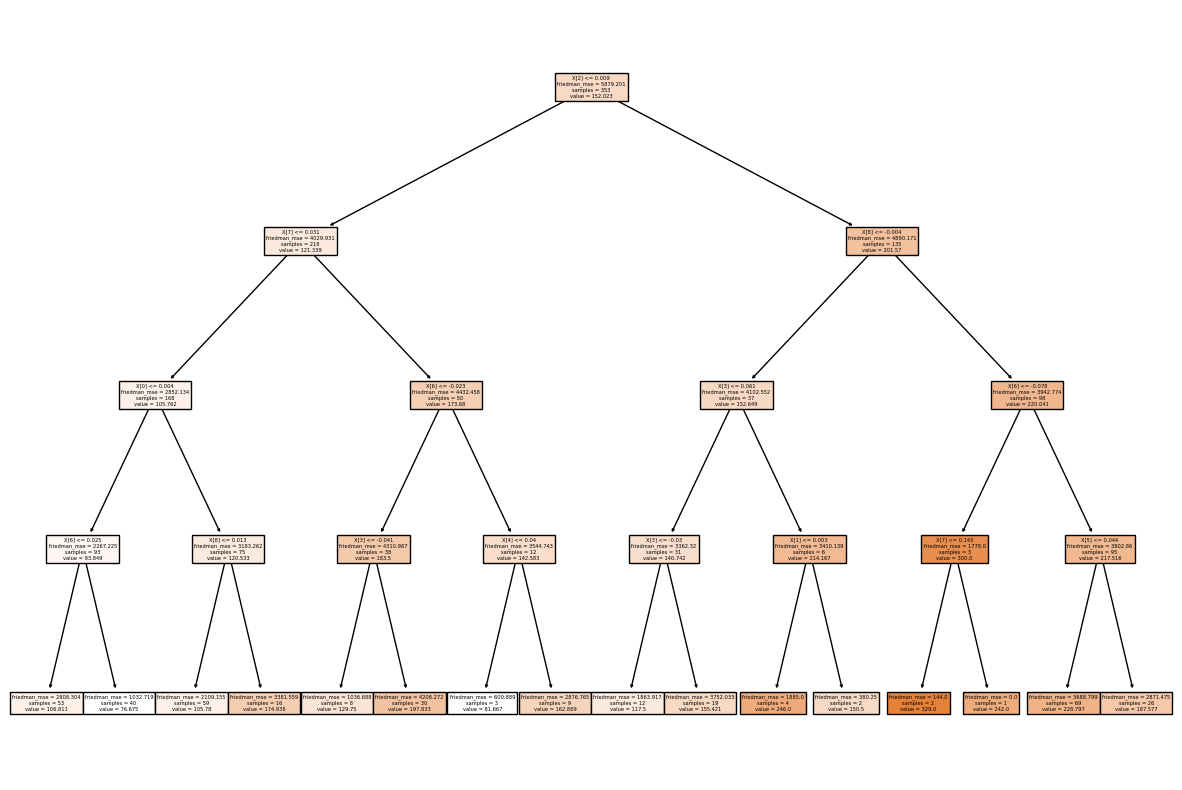

In [43]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(selectmodel,filled=True)